# 04 - Tuning des Hyperparamètres et Interprétation

## Objectifs
- Optimiser les hyperparamètres du meilleur modèle (Logistic Regression)
- Comparer les performances baseline vs tuned
- Analyser l'importance des variables
- Analyser les erreurs de prédiction

## 1. Configuration et imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, confusion_matrix, classification_report)
from sklearn.linear_model import LogisticRegression

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ Imports réussis!")

✓ Imports réussis!


## 2. Chargement des données

In [10]:
# Charger les données train/test sauvegardées par la Personne 3
import os

pkl_path = '../models/train_test_data.pkl'

# Vérifier que le fichier existe (doit être créé par le notebook 03_modeling.ipynb)
if not os.path.exists(pkl_path):
    raise FileNotFoundError(
        f"\n❌ ERREUR: Le fichier '{pkl_path}' n'existe pas!\n\n"
        "📝 ACTION REQUISE: Vous devez d'abord exécuter le notebook '03_modeling.ipynb' "
        "qui crée ce fichier en sauvegardant les données train/test.\n\n"
        "Le notebook 03 doit être exécuté jusqu'à la fin pour générer train_test_data.pkl"
    )

# Charger depuis le fichier pickle
with open(pkl_path, 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

print("✓ Données chargées depuis train_test_data.pkl (créé par la Personne 3)")
print(f"\nDonnées chargées:")
print(f"  - X_train: {X_train.shape}")
print(f"  - X_test: {X_test.shape}")
print(f"  - y_train: {y_train.shape}")
print(f"  - y_test: {y_test.shape}")

✓ Données chargées depuis train_test_data.pkl (créé par la Personne 3)

Données chargées:
  - X_train: (712, 30)
  - X_test: (179, 30)
  - y_train: (712,)
  - y_test: (179,)


## 3. Modèle Baseline

In [18]:
# Modèle baseline (paramètres par défaut)
baseline_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)
y_pred_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]

baseline_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_baseline),
    'precision': precision_score(y_test, y_pred_baseline),
    'recall': recall_score(y_test, y_pred_baseline),
    'f1': f1_score(y_test, y_pred_baseline),
    'roc_auc': roc_auc_score(y_test, y_pred_proba_baseline)
}

print("="*60)
print("MODÈLE BASELINE")
print("="*60)
for metric, value in baseline_metrics.items():
    print(f"  {metric.upper():<12}: {value:.4f}")

MODÈLE BASELINE
  ACCURACY    : 0.8436
  PRECISION   : 0.8060
  RECALL      : 0.7826
  F1          : 0.7941
  ROC_AUC     : 0.8705


## 4. Tuning des Hyperparamètres avec GridSearchCV

In [25]:
# Espace de recherche
param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'lbfgs']
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Démarrage du GridSearchCV...")
grid_search = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print("\n✓ GridSearchCV terminé!")

Démarrage du GridSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✓ GridSearchCV terminé!


In [31]:
print("="*60)
print("MEILLEURS HYPERPARAMÈTRES")
print("="*60)
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nMeilleur score CV (F1): {grid_search.best_score_:.4f}")

MEILLEURS HYPERPARAMÈTRES
  C: 1.0
  penalty: l2
  solver: lbfgs

Meilleur score CV (F1): 0.7683


## 5. Comparaison Baseline vs Tuned

In [32]:
# Modèle optimisé
tuned_model = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)
y_pred_proba_tuned = tuned_model.predict_proba(X_test)[:, 1]

tuned_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_tuned),
    'precision': precision_score(y_test, y_pred_tuned),
    'recall': recall_score(y_test, y_pred_tuned),
    'f1': f1_score(y_test, y_pred_tuned),
    'roc_auc': roc_auc_score(y_test, y_pred_proba_tuned)
}

comparison_df = pd.DataFrame({
    'Baseline': baseline_metrics,
    'Tuned': tuned_metrics
})
comparison_df['Amélioration'] = comparison_df['Tuned'] - comparison_df['Baseline']

print("="*60)
print("COMPARAISON BASELINE vs TUNED")
print("="*60)
print(comparison_df.round(4))

COMPARAISON BASELINE vs TUNED
           Baseline   Tuned  Amélioration
accuracy     0.8436  0.8436           0.0
precision    0.8060  0.8060           0.0
recall       0.7826  0.7826           0.0
f1           0.7941  0.7941           0.0
roc_auc      0.8705  0.8705           0.0


## 6. Importance des Variables (Coefficients)

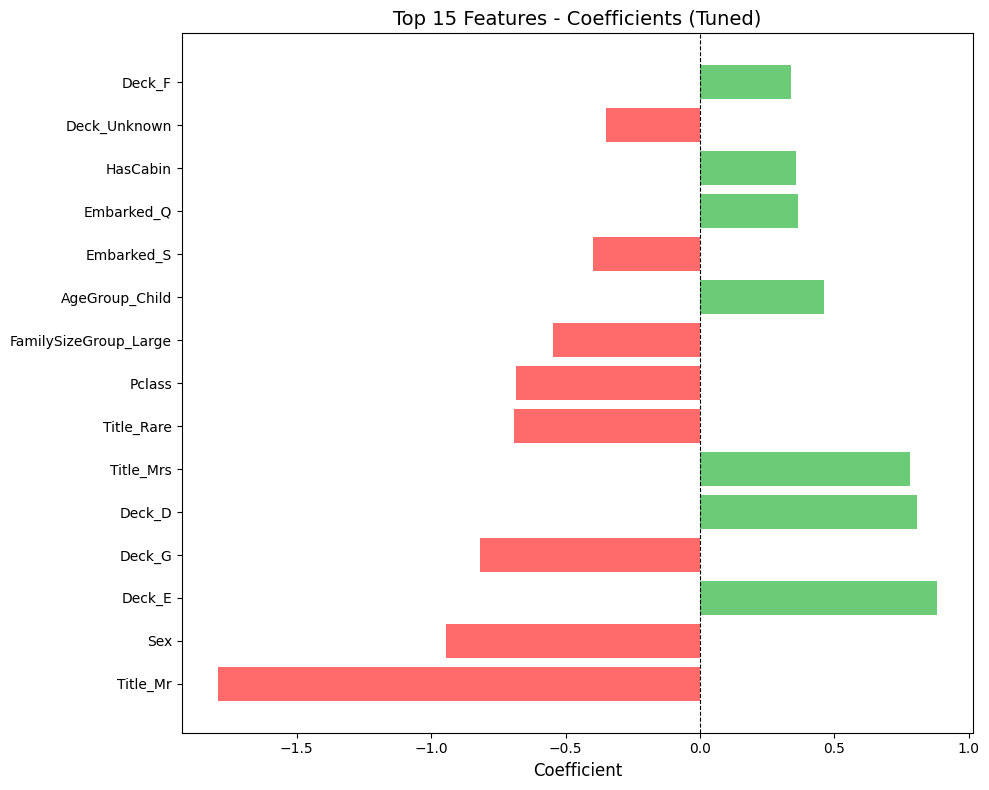


🔝 Top 10 features les plus importantes:
   Title_Mr                      :  -1.7933
   Sex                           :  -0.9449
   Deck_E                        :   0.8818
   Deck_G                        :  -0.8177
   Deck_D                        :   0.8052
   Title_Mrs                     :   0.7822
   Title_Rare                    :  -0.6933
   Pclass                        :  -0.6828
   FamilySizeGroup_Large         :  -0.5473
   AgeGroup_Child                :   0.4609


In [33]:
# Coefficients (importance des features)
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': tuned_model.coef_[0]
})
feature_importance['abs_coefficient'] = feature_importance['coefficient'].abs()
feature_importance = feature_importance.sort_values('abs_coefficient', ascending=False)

# Visualisation top 15
fig, ax = plt.subplots(figsize=(10, 8))
top_features = feature_importance.head(15)
colors = ['#ff6b6b' if x < 0 else '#6bcb77' for x in top_features['coefficient']]
bars = ax.barh(range(len(top_features)), top_features['coefficient'], color=colors)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'])
ax.set_xlabel('Coefficient', fontsize=12)
ax.set_title('Top 15 Features - Coefficients (Tuned)', fontsize=14)
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('../reports/figures/feature_coefficients_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🔝 Top 10 features les plus importantes:")
for idx, row in feature_importance.head(10).iterrows():
    print(f"   {row['feature']:30s}: {row['coefficient']:8.4f}")

## 7. Analyse des Erreurs

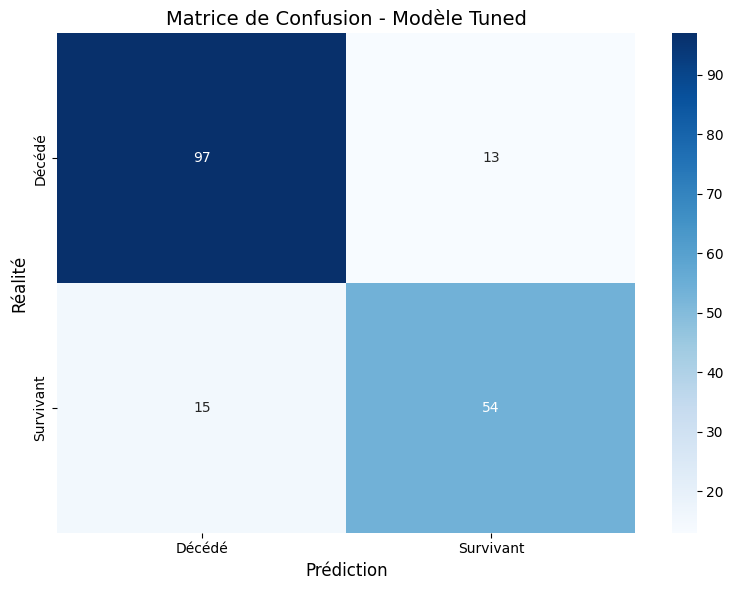


Vrais Négatifs (TN): 97
Faux Positifs (FP): 13
Faux Négatifs (FN): 15
Vrais Positifs (TP): 54


In [34]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_tuned)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Décédé', 'Survivant'],
            yticklabels=['Décédé', 'Survivant'])
ax.set_xlabel('Prédiction', fontsize=12)
ax.set_ylabel('Réalité', fontsize=12)
ax.set_title('Matrice de Confusion - Modèle Tuned', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nVrais Négatifs (TN): {cm[0,0]}")
print(f"Faux Positifs (FP): {cm[0,1]}")
print(f"Faux Négatifs (FN): {cm[1,0]}")
print(f"Vrais Positifs (TP): {cm[1,1]}")

In [35]:
# Sauvegarder le modèle final
joblib.dump(tuned_model, '../models/logistic_regression_tuned.joblib')
comparison_df.to_csv('../models/tuning_comparison.csv')
print("✓ Modèle final et résultats sauvegardés!")

✓ Modèle final et résultats sauvegardés!
